# 02 — MathDial EDA on the paper-filtered population

## Purpose

This notebook describes the exact MathDial population used by the paper's BKT
experiment. Filtering is performed **before** any descriptive statistics, so NA
turns, failed annotations, and one-tagged-turn dialogues cannot distort the EDA.

The notebook has four jobs:

1. Reproduce and audit the paper's filtering on train and test.
2. Assert that the resulting counts match the BKT baseline population.
3. Analyse the retained population through three clusters: dataset shape,
   knowledge components, and misconception structure.
4. Reach independent filtering conclusions from those results, while separating
   data removal from Part 2's model-level fallback decisions.

No rare-KC or degenerate-KC filter is introduced: the paper does not apply one.


## Paper filtering contract

The paper prepares both splits in this order:

1. Keep dialogues whose typical-confusion and typical-interaction scores are at
   least 1.
2. Remove an entire dialogue if its annotation contains an error.
3. Apply turn annotations:
   - a student-initiated turn 0 is unlabelled;
   - a turn without KCs becomes `correctness=None`;
   - any `correctness=None` turn is removed;
   - the literal final dialogue turn is overridden using MathDial
     `self_correctness` when that turn has KCs and a non-NA label.
4. After turn removal, retain a dialogue only if at least two tagged turns remain.
5. Expand retained true turns into one pseudo-observation per KC.

The final-dialogue-turn override is:

| `self_correctness` | Final dialogue-turn result |
| --- | --- |
| `Yes` | correct |
| `No` | incorrect |
| `Yes, but I had to reveal the answer` | `None`, so remove the turn |

The implementation does not search backwards for an earlier tagged turn when
the literal final turn is an untagged closing remark. The paper does **not**
filter KCs by frequency, label variation, or train/test overlap. The first
tagged test turn is excluded later during evaluation, not during preparation.


In [9]:
import os
import sys
from copy import deepcopy
from ast import literal_eval
from collections import Counter
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd()
for _candidate in [_here, *_here.parents]:
    if (_candidate / "data" / "annotated").exists():
        os.chdir(_candidate)
        break
else:
    raise FileNotFoundError(f"Could not find data/annotated above {_here}")

sys.path.insert(0, str(Path.cwd() / "extension"))
from scripts import bkt_paper as bp

DATA = Path("data/annotated")
KC_DICT_PATH = DATA / "kc_dict_mathdial_atc.json"
CONVERTERS = {
    name: literal_eval for name in ["dialogue", "annotation", "meta_data"]
}

def load_raw(split):
    return pd.read_csv(
        DATA / f"mathdial_{split}_atc.csv", converters=CONVERTERS
    )

train_raw = load_raw("train")
test_raw = load_raw("test")
print("working directory:", Path.cwd())
print("raw train dialogues:", len(train_raw))
print("raw test dialogues: ", len(test_raw))


working directory: /Users/tandon.utsav2/Desktop/Experiment_1
raw train dialogues: 2253
raw test dialogues:  595


## Apply the paper filters first

Three related tables are returned:

- `dialogues`: one row per retained dialogue, preserving the original row index;
- `turns`: one row per retained tagged true turn;
- `long`: one row per retained `(dialogue, turn, KC)` pseudo-observation.

Keeping all three units explicit prevents dialogue, true-turn, and KC-mention
counts from being confused.


In [10]:
def passes_typical(sample, cutoff=1):
    meta = sample["meta_data"] if isinstance(sample["meta_data"], dict) else {}
    return (
        meta.get("self_typical_confusion") is not None
        and meta.get("self_typical_interactions") is not None
        and meta["self_typical_confusion"] >= cutoff
        and meta["self_typical_interactions"] >= cutoff
    )

def paper_prepare(raw, split, typical_cutoff=1):
    typical = raw[raw.apply(
        lambda row: passes_typical(row, typical_cutoff), axis=1
    )]

    failed = 0
    fewer_than_two = 0
    kept_ids = []
    turn_rows = []
    pseudo_rows = []

    for dialogue_idx, sample in typical.iterrows():
        # The mirror follows the paper's apply_annotations logic, including the
        # final-turn override. Deepcopy avoids mutating the raw nested objects.
        dialogue = bp.apply_annotations(deepcopy(sample.to_dict()))
        if dialogue is None:
            failed += 1
            continue

        tagged = [
            turn for turn in dialogue
            if turn["correct"] is not None and turn["kcs"]
        ]
        if len(tagged) < 2:
            fewer_than_two += 1
            continue

        kept_ids.append(dialogue_idx)
        for turn in tagged:
            label = int(bool(turn["correct"]))
            turn_rows.append({
                "dialogue_idx": dialogue_idx,
                "turn": int(turn["turn"]),
                "correct": label,
                "n_kcs": len(turn["kcs"]),
            })
            for kc in turn["kcs"]:
                pseudo_rows.append({
                    "dialogue_idx": dialogue_idx,
                    "turn": int(turn["turn"]),
                    "correct": label,
                    "kc": str(kc),
                })

    dialogues = typical.loc[kept_ids].copy()
    turns = pd.DataFrame(turn_rows)
    long = pd.DataFrame(pseudo_rows)

    audit = {
        "split": split,
        "raw_dialogues": len(raw),
        "after_typical_cutoff_1": len(typical),
        "failed_dialogues_removed": failed,
        "fewer_than_2_tagged_removed": fewer_than_two,
        "dialogues_kept": len(dialogues),
        "tagged_true_turns": len(turns),
        "kc_pseudo_observations": len(long),
        "distinct_kcs": long["kc"].nunique(),
        "test_style_scored_turns": len(turns) - len(dialogues),
    }
    return dialogues, turns, long, audit

train_dialogues, train_turns, train_long, train_audit = paper_prepare(
    train_raw, "train"
)
test_dialogues, test_turns, test_long, test_audit = paper_prepare(
    test_raw, "test"
)

audit = pd.DataFrame([train_audit, test_audit]).set_index("split")
print(audit.to_string())


       raw_dialogues  after_typical_cutoff_1  failed_dialogues_removed  fewer_than_2_tagged_removed  dialogues_kept  tagged_true_turns  kc_pseudo_observations  distinct_kcs  test_style_scored_turns
split                                                                                                                                                                                                
train           2253                    2253                        18                          185            2050              10448                   23953           138                     8398
test             595                     595                         7                           73             515               2500                    5788            94                     1985


## Validate the replicated population

These assertions are deliberately strict. If the released annotation files or
filter implementation change, the notebook should fail rather than silently
describe a different population.

The `test_style_scored_turns` column subtracts one first tagged turn per dialogue.
It describes the paper's evaluation population; training still uses every tagged
training turn.


In [11]:
EXPECTED = {
    "train": {
        "raw_dialogues": 2253,
        "failed_dialogues_removed": 18,
        "fewer_than_2_tagged_removed": 185,
        "dialogues_kept": 2050,
        "tagged_true_turns": 10448,
        "kc_pseudo_observations": 23953,
        "distinct_kcs": 138,
    },
    "test": {
        "raw_dialogues": 595,
        "failed_dialogues_removed": 7,
        "fewer_than_2_tagged_removed": 73,
        "dialogues_kept": 515,
        "tagged_true_turns": 2500,
        "kc_pseudo_observations": 5788,
        "distinct_kcs": 94,
        "test_style_scored_turns": 1985,
    },
}

for split, observed in [("train", train_audit), ("test", test_audit)]:
    for field, expected in EXPECTED[split].items():
        actual = observed[field]
        assert actual == expected, (
            f"{split}.{field}: expected {expected}, observed {actual}"
        )

assert not train_turns["correct"].isna().any()
assert not test_turns["correct"].isna().any()
assert (train_turns.groupby("dialogue_idx").size() >= 2).all()
assert (test_turns.groupby("dialogue_idx").size() >= 2).all()
assert train_long.groupby(["dialogue_idx", "turn"])["correct"].nunique().eq(1).all()
assert test_long.groupby(["dialogue_idx", "turn"])["correct"].nunique().eq(1).all()

print("paper-filter replication checks: PASSED")


paper-filter replication checks: PASSED


# Cluster 1: Dataset shape and correctness

This first cluster establishes the scale of the exact population seen by BKT.
Everything below uses the retained tables, not the raw annotation dictionary.
The reported correctness balance therefore reflects:

- removal of NA/no-KC turns;
- the final-turn human outcome override;
- removal of dialogues with fewer than two usable tagged turns.

We keep three units separate: dialogues, true turns, and per-KC pseudo-
observations. Correctness is evaluated per true turn; counting pseudo-rows would
overweight turns carrying many KCs.


       dialogues  true_turns  pseudo_observations  fraction_correct  majority_accuracy  mean_turns_per_dialogue  median_turns_per_dialogue  min_turns  max_turns  mean_kcs_per_turn
split                                                                                                                                                                              
train       2050       10448                23953             0.498              0.502                    5.097                        5.0          2         20              2.293
test         515        2500                 5788             0.460              0.540                    4.854                        4.0          2         13              2.315

correctness by counting unit:
       correct_per_true_turn  correct_per_pseudo_observation  labels_constant_within_turn
split                                                                                    
train                  0.498                           0.497         

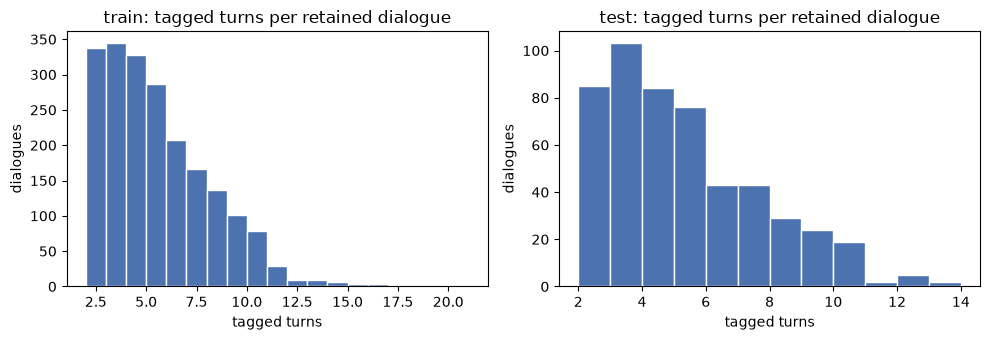

In [12]:
summary_rows = []
for split, dialogues, turns, long in [
    ("train", train_dialogues, train_turns, train_long),
    ("test", test_dialogues, test_turns, test_long),
]:
    lengths = turns.groupby("dialogue_idx").size()
    fraction_correct = turns["correct"].mean()
    summary_rows.append({
        "split": split,
        "dialogues": len(dialogues),
        "true_turns": len(turns),
        "pseudo_observations": len(long),
        "fraction_correct": fraction_correct,
        "majority_accuracy": max(fraction_correct, 1 - fraction_correct),
        "mean_turns_per_dialogue": lengths.mean(),
        "median_turns_per_dialogue": lengths.median(),
        "min_turns": lengths.min(),
        "max_turns": lengths.max(),
        "mean_kcs_per_turn": len(long) / len(turns),
    })

shape_summary = pd.DataFrame(summary_rows).set_index("split")
print(shape_summary.round(3).to_string())

# Correctness belongs to a true turn and must be constant across all of that
# turn's pseudo-observations. Report both units to expose any weighting effect.
correctness_rows = []
for split, turns, long in [
    ("train", train_turns, train_long),
    ("test", test_turns, test_long),
]:
    consistent = (
        long.groupby(["dialogue_idx", "turn"])["correct"].nunique().eq(1).all()
    )
    correctness_rows.append({
        "split": split,
        "correct_per_true_turn": turns["correct"].mean(),
        "correct_per_pseudo_observation": long["correct"].mean(),
        "labels_constant_within_turn": consistent,
    })
correctness_summary = pd.DataFrame(correctness_rows).set_index("split")
print("\ncorrectness by counting unit:")
print(correctness_summary.round(3).to_string())

# The paper scores test turns only after the first retained tagged turn in each
# dialogue. This is an evaluation view, not another preparation filter.
test_scored = test_turns[
    test_turns.sort_values(["dialogue_idx", "turn"])
    .groupby("dialogue_idx").cumcount().gt(0)
].copy()
assert len(test_scored) == test_audit["test_style_scored_turns"]
scored_fraction_correct = test_scored["correct"].mean()
print(
    f"\npaper-scored test turns: {len(test_scored)} | "
    f"correct={scored_fraction_correct:.3f} | "
    f"majority accuracy={max(scored_fraction_correct, 1-scored_fraction_correct):.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (split, turns) in zip(
    axes, [("train", train_turns), ("test", test_turns)]
):
    lengths = turns.groupby("dialogue_idx").size()
    ax.hist(
        lengths,
        bins=range(int(lengths.min()), int(lengths.max()) + 2),
        color="#4C72B0",
        edgecolor="white",
    )
    ax.set_title(f"{split}: tagged turns per retained dialogue")
    ax.set_xlabel("tagged turns")
    ax.set_ylabel("dialogues")
plt.tight_layout()
plt.show()


## Cluster 1 conclusions

After paper filtering, train contains 2,050 dialogues / 10,448 true turns and
test contains 515 dialogues / 2,500 true turns. Train is almost exactly balanced
(49.8% correct); test is 46.0% correct before the evaluation shift. Once the
first tagged test turn is excluded, the 1,985 scored turns are 47.4% correct and
the majority-class accuracy is 52.6%. This scored-turn figure is the appropriate
constant baseline for paper metrics.

Per-turn and per-pseudo-observation correctness are nearly identical, and the
assertion confirms that every KC attached to a turn shares the same label. Even
so, all predictive metrics should remain turn-level so a turn with many KCs does
not receive more weight merely because of its annotation density.

Dialogues remain short (median 5 train and 4 test tagged turns), but the minimum
is now two by construction. The two-turn rule is structurally justified because
the first test turn is context-only; a one-turn dialogue would contribute no
scored target. Further length thresholds would discard valid evaluated targets
and should be examined only as performance strata.


# Cluster 2: Knowledge components

This cluster examines KC coverage, frequency, label variation, KCs per turn, and
train/test overlap after paper preparation. These diagnostics tell us where BKT
must estimate sparse parameters, but they do not themselves justify deleting
observations. Every filtering decision must be made using training statistics;
test is used here only to measure the consequence for evaluation coverage.


KCs in dictionary: 149
observed train KCs: 138
observed test KCs:  94
unused in both retained splits: 5
rare train KCs: {'<= 1': 12, '<= 2': 21, '<= 5': 45, '<= 10': 58}
degenerate train KCs: 20 (all-incorrect=7, all-correct=13) | observations: 37 (0.15%)
test-only KCs: 6 | test pseudo-rows: 17 | affected true turns: 11
KCs per retained train turn: mean=2.29 | median=2 | min=1 | max=18

most frequent degenerate KCs:
  n= 4 | all-correct   | Use facts about supplementary, complementary, vertical, and adjacent angles
  n= 4 | all-incorrect | Explain why addition and subtraction strategies work, using place value and
  n= 4 | all-correct   | Understand that shapes in different categories (e.g., rhombuses, rectangles
  n= 3 | all-correct   | Distinguish between defining attributes (e.g., triangles are closed and thr
  n= 3 | all-correct   | Find the area of right triangles, other triangles, special quadrilaterals, 
  n= 3 | all-correct   | Recognize and draw shapes having specified attribu

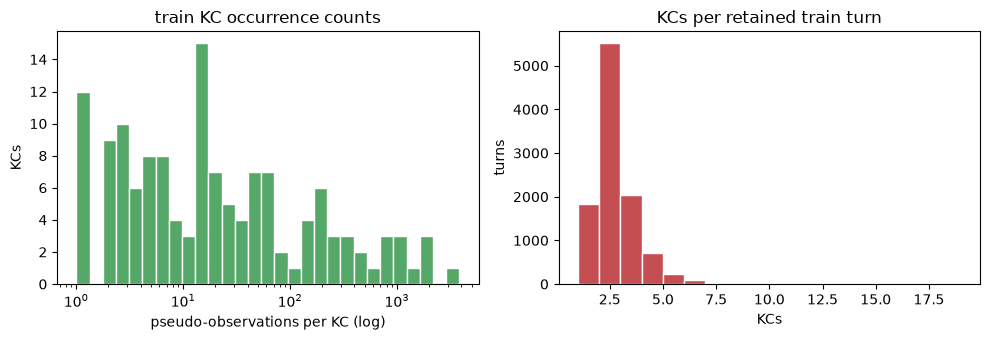

In [13]:
kc_dict = json.loads(KC_DICT_PATH.read_text())

train_kc_stats = train_long.groupby("kc")["correct"].agg(
    n="count", n_correct="sum"
)
test_kc_stats = test_long.groupby("kc")["correct"].agg(
    n="count", n_correct="sum"
)
degenerate = train_kc_stats[
    (train_kc_stats["n_correct"] == 0)
    | (train_kc_stats["n_correct"] == train_kc_stats["n"])
]
all_incorrect = degenerate[degenerate["n_correct"] == 0]
all_correct = degenerate[degenerate["n_correct"] == degenerate["n"]]

rare_counts = {
    f"<= {threshold}": int((train_kc_stats["n"] <= threshold).sum())
    for threshold in [1, 2, 5, 10]
}
train_kcs = set(train_long["kc"])
test_kcs = set(test_long["kc"])
dictionary_kcs = set(kc_dict)
unused_dictionary_kcs = dictionary_kcs - train_kcs - test_kcs
test_only = test_kcs - train_kcs
test_only_rows = int(test_long["kc"].isin(test_only).sum())
test_only_turns = test_long.loc[
    test_long["kc"].isin(test_only), ["dialogue_idx", "turn"]
].drop_duplicates()
kcs_per_turn = train_turns["n_kcs"]

print("KCs in dictionary:", len(kc_dict))
print("observed train KCs:", len(train_kc_stats))
print("observed test KCs: ", len(test_kc_stats))
print("unused in both retained splits:", len(unused_dictionary_kcs))
print("rare train KCs:", rare_counts)
print(
    "degenerate train KCs:",
    len(degenerate),
    f"(all-incorrect={len(all_incorrect)}, all-correct={len(all_correct)})",
    "| observations:",
    int(degenerate["n"].sum()),
    f"({100 * degenerate['n'].sum() / len(train_long):.2f}%)",
)
print(
    "test-only KCs:", len(test_only),
    "| test pseudo-rows:", test_only_rows,
    "| affected true turns:", len(test_only_turns),
)
print(
    f"KCs per retained train turn: mean={kcs_per_turn.mean():.2f} | "
    f"median={kcs_per_turn.median():.0f} | min={kcs_per_turn.min()} | "
    f"max={kcs_per_turn.max()}"
)

print("\nmost frequent degenerate KCs:")
for kc, row in degenerate.sort_values("n", ascending=False).head(8).iterrows():
    label = "all-correct" if row["n_correct"] == row["n"] else "all-incorrect"
    print(f"  n={int(row['n']):>2} | {label:<13} | {kc[:75]}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(
    train_kc_stats["n"],
    bins=np.logspace(0, np.log10(train_kc_stats["n"].max()), 30),
    color="#55A868",
    edgecolor="white",
)
axes[0].set_xscale("log")
axes[0].set_title("train KC occurrence counts")
axes[0].set_xlabel("pseudo-observations per KC (log)")
axes[0].set_ylabel("KCs")

axes[1].hist(
    train_turns["n_kcs"],
    bins=range(1, int(train_turns["n_kcs"].max()) + 2),
    color="#C44E52",
    edgecolor="white",
)
axes[1].set_title("KCs per retained train turn")
axes[1].set_xlabel("KCs")
axes[1].set_ylabel("turns")
plt.tight_layout()
plt.show()


## Cluster 2 conclusions

The paper-filtered train population has:

- 138 of the 149 dictionary KCs observed in train and 94 in test;
- a long frequency tail: 12 KCs occur once, 21 at most twice, and 45 at most
  five times;
- 20 degenerate train KCs covering 37 pseudo-observations (0.15%);
- 6 test-only KCs covering 17 test pseudo-observations;
- 2.29 KCs per retained train turn on average.

The long tail demonstrates parameter uncertainty, not annotation invalidity. A
frequency cutoff would be arbitrary without external evidence that the rare KCs
are wrong. It would also alter multi-KC turns selectively: deleting one KC does
not necessarily delete the underlying true-turn correctness observation.

Degenerate and test-only KCs cannot support their own full BKT parameter estimate,
but that is an estimation problem rather than a reason to remove their turns.
Deleting them would make evaluation coverage depend on what happened to appear
in train. The primary analysis should retain them and use a training-derived,
pre-specified fallback; deletion belongs only in a labelled sensitivity analysis.

Part 2's weighted pooled parameters implement that fallback while retaining every
pseudo-observation. Finally, because one correctness label is repeated across all
KCs on a turn, model scoring must be aggregated at the true-turn level.


# Cluster 3: Misconception structure

This cluster asks whether the misconception variables remain usable after paper
filtering. It separates the six recurring `student_profile` families from the
near-unique `teacher_described_confusion`, reports the retained final-outcome
distribution, and checks whether any family is nearly deterministic with respect
to correctness. The family analysis is descriptive; it does not enter the paper's
BKT filtering contract.


retained dialogues by misconception family:
                                     train  test
family                                          
A: misunderstands what problem asks    382    89
B: weak principles / when to apply     352    97
C: relevant vs irrelevant info         293    86
D: wrong operation / number order      352    93
E: unsure which steps/procedures       333    72
F: cannot recognise problem type       338    78

retained true turns by family:
                                     train  test
family                                          
A: misunderstands what problem asks   1930   397
B: weak principles / when to apply    1698   468
C: relevant vs irrelevant info        1531   435
D: wrong operation / number order     1912   448
E: unsure which steps/procedures      1671   349
F: cannot recognise problem type      1706   403

mean true-turn correctness by family:
                                     train   test
family                                           
A

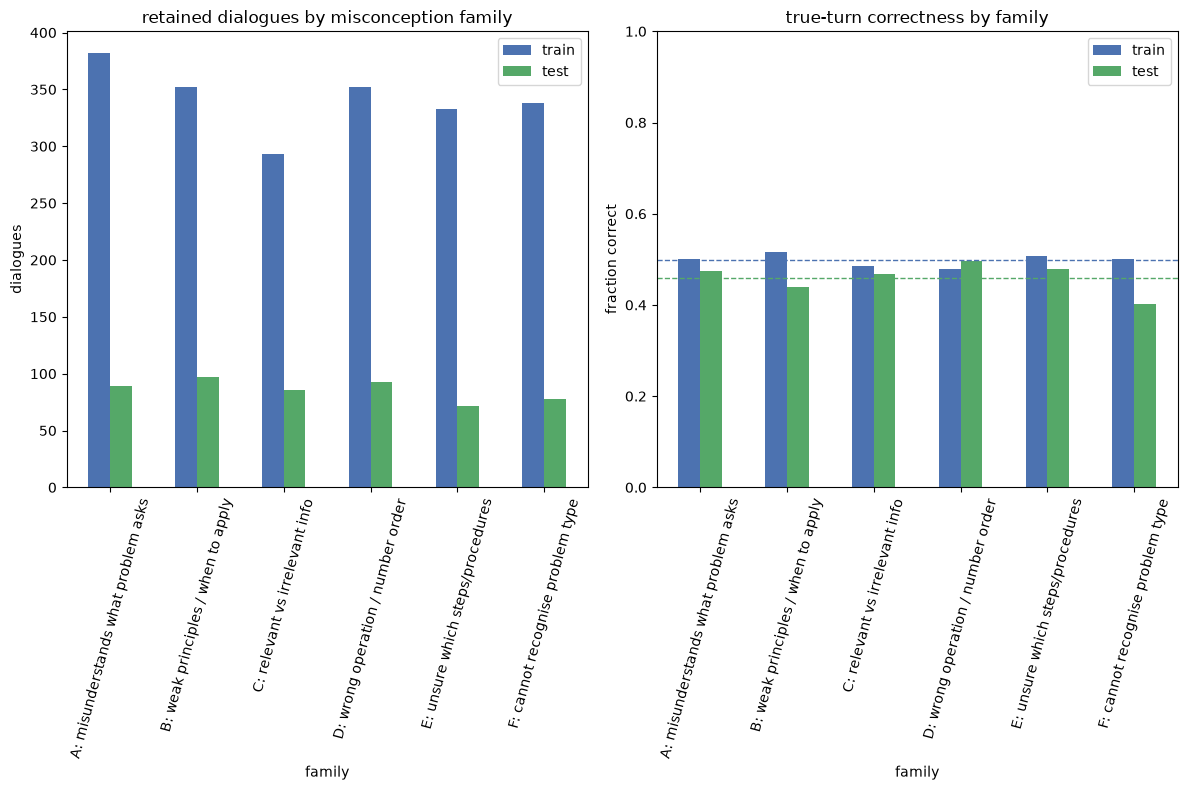

In [14]:
import re

def misconception_family(profile):
    trait = re.sub(
        r"^[A-Za-z]+ is a [^.]+\.\s*", "", str(profile).strip()
    ).lower()
    if "what the problem is asking" in trait:
        return "A: misunderstands what problem asks"
    if "underlying ideas and principles" in trait:
        return "B: weak principles / when to apply"
    if "relevant" in trait and "irrelevant" in trait:
        return "C: relevant vs irrelevant info"
    if "correct order" in trait or "correct operation" in trait:
        return "D: wrong operation / number order"
    if "steps or procedures" in trait:
        return "E: unsure which steps/procedures"
    if "recognize the problem type" in trait:
        return "F: cannot recognise problem type"
    return "OTHER"

for dialogues in [train_dialogues, test_dialogues]:
    dialogues["family"] = dialogues["student_profile"].map(
        misconception_family
    )
    assert "OTHER" not in set(dialogues["family"])

def attach_family(turns, dialogues):
    result = turns.copy()
    result["family"] = result["dialogue_idx"].map(dialogues["family"])
    assert result["family"].notna().all()
    return result

train_turn_family = attach_family(train_turns, train_dialogues)
test_turn_family = attach_family(test_turns, test_dialogues)

family_counts = pd.concat(
    {
        "train": train_dialogues["family"].value_counts().sort_index(),
        "test": test_dialogues["family"].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)
family_correctness = pd.concat(
    {
        "train": train_turn_family.groupby("family")["correct"].mean(),
        "test": test_turn_family.groupby("family")["correct"].mean(),
    },
    axis=1,
)
family_turn_counts = pd.concat(
    {
        "train": train_turn_family["family"].value_counts().sort_index(),
        "test": test_turn_family["family"].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)

confusion_uniqueness = pd.DataFrame(
    [
        {
            "split": split,
            "dialogues": len(dialogues),
            "distinct_described_confusions": dialogues[
                "teacher_described_confusion"
            ].nunique(),
        }
        for split, dialogues in [
            ("train", train_dialogues), ("test", test_dialogues)
        ]
    ]
).set_index("split")
confusion_uniqueness["fraction_unique"] = (
    confusion_uniqueness["distinct_described_confusions"]
    / confusion_uniqueness["dialogues"]
)

resolution = pd.concat(
    {
        "train": train_dialogues["self-correctness"].value_counts(),
        "test": test_dialogues["self-correctness"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

print("retained dialogues by misconception family:")
print(family_counts.to_string())
print("\nretained true turns by family:")
print(family_turn_counts.to_string())
print("\nmean true-turn correctness by family:")
print(family_correctness.round(3).to_string())
print("\ndescribed-confusion uniqueness:")
print(confusion_uniqueness.round(3).to_string())
print("\nself-correctness among retained dialogues:")
print(resolution.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
family_counts.plot.bar(ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("retained dialogues by misconception family")
axes[0].set_xlabel("family")
axes[0].set_ylabel("dialogues")
axes[0].tick_params(axis="x", rotation=75)

family_correctness.plot.bar(ax=axes[1], color=["#4C72B0", "#55A868"])
axes[1].axhline(train_turns["correct"].mean(), color="#4C72B0", ls="--", lw=1)
axes[1].axhline(test_turns["correct"].mean(), color="#55A868", ls="--", lw=1)
axes[1].set_ylim(0, 1)
axes[1].set_title("true-turn correctness by family")
axes[1].set_xlabel("family")
axes[1].set_ylabel("fraction correct")
axes[1].tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()


## Cluster 3 conclusions

The six misconception families all survive paper filtering with substantial
support: 293–382 retained train dialogues per family and 72–97 test dialogues.
No train family is close to deterministic correctness (family means range from
47.9% to 51.7%). Test means vary more, from 40.2% to 49.6%, especially for the
`cannot recognise problem type` family. This is a possible distribution shift
to report or stratify by, not a reason to remove a family.

The six profile families are therefore viable recurring categorical context.
The described confusion is 99.5% unique in train and 99.6% unique in test, so it
should remain textual/extraction context rather than be treated as a categorical
skill. Neither field supplies evidence for an additional population filter.

The retained `self-correctness` distribution contains all three outcomes. It is
not an input filter by itself: its role is to correct the literal final dialogue
turn, and reveal-answer outcomes remove that final label by setting it to NA.


# Independent review of filtering decisions

Before deciding whether the baseline needs more filtering, quantify the effects
that are easy to obscure: how often the human final outcome changes a model label,
how much stricter typicality would remove, and how rapidly extra dialogue-length
thresholds would shrink the retained population.


In [15]:
def final_override_audit(raw):
    transitions = Counter()
    for _, sample in raw.iterrows():
        if not passes_typical(sample, 1):
            continue
        copied = deepcopy(sample.to_dict())
        if "error" in copied["annotation"]:
            continue

        final_turn = copied["dialogue"][-1]
        original = copied["annotation"].get(f"turn {final_turn['turn']}")
        eligible = (
            isinstance(original, dict)
            and bool(original.get("kcs"))
            and original.get("correct") is not None
        )
        if not eligible:
            transitions["not eligible"] += 1
            continue

        before = bool(original["correct"])
        after = bp.apply_annotations(copied)[-1]["correct"]
        after_label = "NA" if after is None else str(bool(after))
        transitions[f"{before} -> {after_label}"] += 1
        transitions["eligible"] += 1
        if after is None or bool(after) != before:
            transitions["changed or removed"] += 1
    return transitions

override_rows = []
for split, raw in [("train", train_raw), ("test", test_raw)]:
    result = final_override_audit(raw)
    override_rows.append({
        "split": split,
        "eligible_final_turns": result["eligible"],
        "changed_or_removed": result["changed or removed"],
        "fraction_changed_or_removed": (
            result["changed or removed"] / result["eligible"]
        ),
        "not_eligible": result["not eligible"],
        "False_to_True": result["False -> True"],
        "True_to_False": result["True -> False"],
        "to_NA": result["True -> NA"] + result["False -> NA"],
    })
override_summary = pd.DataFrame(override_rows).set_index("split")
print("final-turn override impact:")
print(override_summary.round(3).to_string())

typicality = pd.DataFrame(
    {
        "cutoff_1": [
            train_raw.apply(lambda row: passes_typical(row, 1), axis=1).sum(),
            test_raw.apply(lambda row: passes_typical(row, 1), axis=1).sum(),
        ],
        "cutoff_2": [
            train_raw.apply(lambda row: passes_typical(row, 2), axis=1).sum(),
            test_raw.apply(lambda row: passes_typical(row, 2), axis=1).sum(),
        ],
    },
    index=["train", "test"],
)
print("\ntypicality retention before other filters:")
print(typicality.to_string())

length_sensitivity_rows = []
for split, turns in [("train", train_turns), ("test", test_turns)]:
    lengths = turns.groupby("dialogue_idx").size()
    for minimum in [2, 3, 4, 5, 6]:
        kept = int((lengths >= minimum).sum())
        length_sensitivity_rows.append({
            "split": split,
            "minimum_tagged_turns": minimum,
            "dialogues_kept": kept,
            "fraction_of_paper_population": kept / len(lengths),
        })
length_sensitivity = pd.DataFrame(length_sensitivity_rows)
print("\nextra minimum-length sensitivity:")
print(
    length_sensitivity.pivot(
        index="minimum_tagged_turns",
        columns="split",
        values=["dialogues_kept", "fraction_of_paper_population"],
    ).round(3).to_string()
)


final-turn override impact:
       eligible_final_turns  changed_or_removed  fraction_changed_or_removed  not_eligible  False_to_True  True_to_False  to_NA
split                                                                                                                          
train                  1887                 413                        0.219           348            117             45    251
test                    501                 118                        0.236            87             24             14     80

typicality retention before other filters:
       cutoff_1  cutoff_2
train      2253      2021
test        595       541

extra minimum-length sensitivity:
                     dialogues_kept         fraction_of_paper_population       
split                          test   train                         test  train
minimum_tagged_turns                                                           
2                             515.0  2050.0                    

# Filtering decisions from this analysis

These are conclusions from the filtered data and model target—not merely a list
of what the paper happened to do.

1. **Retain the cutoff-1 typicality rule, while recognising it is inert here.**
   Every released train and test dialogue passes, so it provides provenance
   consistency but has no empirical effect on this release. Cutoff 2 would remove
   232 train and 54 test dialogues without a model-based justification; do not use
   it in the primary analysis.
2. **Remove failed-annotation dialogues in full.** Their labels are unavailable,
   so individual turns cannot be distinguished as valid. Whole-dialogue removal
   is the defensible provenance decision and prevents partial sequences.
3. **Exclude no-KC and `correctness=None` turns.** They do not define a BKT
   observation. Treating NA as incorrect would change the target and substantially
   distort the class balance.
4. **Keep the human final-turn override.** It changes or removes 21.9% of eligible
   train final turns and 23.6% of eligible test final turns, so it is consequential.
   It reconciles the generated turn annotation with MathDial's recorded final
   outcome. Document the exact limitation: only the literal final dialogue turn
   is eligible; the code does not search backwards past an untagged closing turn.
5. **Require at least two usable tagged turns.** Because the first test turn is
   context-only, this is the minimum that guarantees one scored target. It is a
   structural eligibility rule, not performance-based selection.
6. **Do not impose a stricter primary length filter.** Raising the minimum from 2
   to 3 already removes 337/2,050 train dialogues and 85/515 test dialogues. At a
   minimum of 5, roughly half the retained population remains. Report performance
   by sequence length instead of changing the main population.
7. **Do not delete rare, degenerate, or test-only KCs in the primary analysis.**
   Degenerate KCs account for only 0.15% of train pseudo-observations and test-only
   KCs affect only 11 true test turns. Their instability calls for a pre-specified
   pooled fallback, not post-hoc coverage removal. A deletion run may be reported
   as sensitivity analysis.
8. **Do not filter misconception families or multi-KC turns.** Every family has
   substantial support and label variation. Multi-KC turns are intrinsic to the
   annotation; retain them, combine their KC evidence in the model, and score once
   per true turn.

The resulting recommendation is the existing paper-prepared population plus
Part 2's training-derived pooled fallback for KCs whose individual parameters
cannot be estimated. This preserves benchmark comparability and observation
coverage while keeping model-estimation choices explicit.
